# 기초통계 통합 프로젝트
## Part 4. 방문횟수를 이용한 구매금액 회귀예측

### 시나리오

Part 3에서는 월간 방문횟수와 구매금액의 산점도와 상관계수를 확인했습니다.

온라인 쇼핑몰 운영팀은 두 변수 사이의 관계를 확인하는 것에서 나아가,
고객의 월간 방문횟수를 이용하여 구매금액을 어느 정도 예측할 수 있는지 확인하려고 합니다.

분석팀은 방문횟수를 독립변수, 구매금액을 종속변수로 설정하여
가장 기본적인 단순 선형회귀 모델을 만들고 회귀계수와 R²를 해석해야 합니다.


### 과제 목표

#### 필수 목표
- 독립변수와 종속변수를 구분할 수 있습니다.
- 단순 선형회귀 모델을 학습할 수 있습니다.
- 회귀계수와 절편을 확인하고 회귀식을 작성할 수 있습니다.
- 회귀선을 산점도와 함께 시각화할 수 있습니다.
- R²를 계산하여 모델의 설명력을 해석할 수 있습니다.
- 새로운 방문횟수에 대한 구매금액을 예측할 수 있습니다.

#### 심화 목표
- 방문횟수 하나만 사용하는 단순회귀 모델의 한계를 설명할 수 있습니다.
- 구매금액 예측을 개선하기 위해 추가로 고려할 변수를 제안하고 이유를 설명할 수 있습니다.

### 사용 환경

- 결과물: `.ipynb` 파일 1개
- 사용 언어: Python 3.X
- 사용 라이브러리: pandas, matplotlib, scikit-learn
- 사용 데이터: `online_shopping_customer_data.csv`


## 제공 코드. 회귀분석 데이터 준비

아래 코드는 준비 코드이며 평가 대상이 아닙니다.

Part 3과 동일한 기준으로 `MonthlyVisitCount`, `PurchaseAmount`에 결측치가 없는 고객을 선택하여
회귀분석용 데이터 `relation_df`를 생성합니다.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

DATA_FILE = "online_shopping_customer_data.csv"

df = pd.read_csv(DATA_FILE)

regression_columns = ["MonthlyVisitCount","PurchaseAmount"]

relation_df = df.dropna(subset=regression_columns).copy()

print("회귀분석에 사용할 고객 수:", len(relation_df))

relation_df[regression_columns].head()


회귀분석에 사용할 고객 수: 487


,MonthlyVisitCount,PurchaseAmount
0,6.0,86900.0
1,10.0,287500.0
2,11.0,242100.0
3,15.0,300500.0
4,8.0,171400.0


# 문제 1. 독립변수와 종속변수 설정 및 회귀모델 학습

## 업무 상황

분석팀은 방문횟수를 이용하여 구매금액을 예측하는
단순 선형회귀 모델을 만들려고 합니다.

## 요구사항

1. `MonthlyVisitCount`를 독립변수 `X`로 설정합니다.
2. `PurchaseAmount`를 종속변수 `y`로 설정합니다.
3. `LinearRegression` 모델을 생성합니다.
4. 전체 데이터를 이용하여 모델을 학습합니다.
5. 학습에 사용한 `X`, `y`의 크기를 출력합니다.

## 힌트

- scikit-learn의 독립변수는 하나의 컬럼이라도 2차원 형태로 작성합니다.
- `X = relation_df[["MonthlyVisitCount"]]`와 같이 이중 대괄호를 사용할 수 있습니다.


In [5]:
# 문제 1 코드를 작성하세요.
from sklearn.linear_model import LinearRegression

# 1. 
X = relation_df[["MonthlyVisitCount"]]

# 2.
y = relation_df["PurchaseAmount"]

# 3. 
model = LinearRegression()

# 4. 
model.fit(X, y)

# 5. 
print(f"X의 크기: {X.shape}")
print(f"y의 크기: {y.shape}")

X의 크기: (487, 1)
y의 크기: (487,)


# 문제 2. 회귀계수·절편 확인 및 회귀선 시각화

## 업무 상황

운영팀은 방문횟수가 한 번 증가할 때
예측 구매금액이 얼마나 변하는지 확인하고 싶어 합니다.

## 요구사항

1. 학습된 모델의 회귀계수를 출력합니다.
2. 학습된 모델의 절편을 출력합니다.
3. 다음 형태로 회귀식을 작성합니다.

   `예측 구매금액 = 절편 + 회귀계수 × 방문횟수`

4. 실제 고객 데이터의 산점도를 생성합니다.
5. 산점도 위에 학습된 회귀선을 표시합니다.
6. 회귀계수의 의미를 한 문장으로 작성합니다.


회귀계수: 19052.6530
절편: 26060.0435
회귀식: 예측 구매금액 = 26060.04 + 19052.65 × 방문횟수


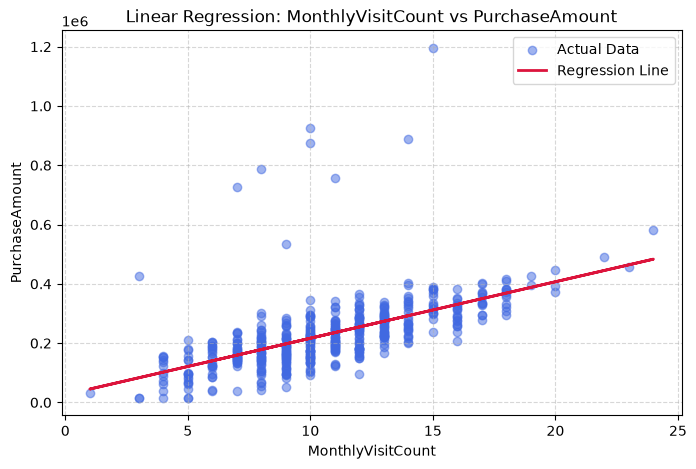

회귀계수의 의미:
회귀계수 19052.65는 고객의 월간 방문횟수가 1회 증가할 때마다 예측 구매금액이 약 19,053원 증가한다는 것을 의미합니다.


In [11]:
# 문제 2 코드를 작성하세요.
import matplotlib.pyplot as plt

# 1. 
slope= model.coef_[0]
print(f"회귀계수: {slope:.4f}")

# 2. 
intercept= model.intercept_
print(f"절편: {intercept:.4f}")

# 3. 
print(f"회귀식: 예측 구매금액 = {intercept:.2f} + {slope:.2f} × 방문횟수")

# 4~5. 
plt.figure(figsize= (8, 5))

plt.scatter(
    relation_df["MonthlyVisitCount"], 
    relation_df["PurchaseAmount"], 
    alpha= 0.5, 
    color= "royalblue", 
    label= "Actual Data"
)

pred_y= model.predict(X)
plt.plot(relation_df["MonthlyVisitCount"], pred_y, color="crimson", linewidth=2, label="Regression Line")

plt.title("Linear Regression: MonthlyVisitCount vs PurchaseAmount")
plt.xlabel("MonthlyVisitCount")
plt.ylabel("PurchaseAmount")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 6. 
print("회귀계수의 의미:")
print(f"회귀계수 {slope:.2f}는 고객의 월간 방문횟수가 1회 증가할 때마다 예측 구매금액이 약 {slope:,.0f}원 증가한다는 것을 의미합니다.")

# 문제 3. 모델 설명력 평가 및 구매금액 예측

## 업무 상황

분석팀은 방문횟수 하나만으로 구매금액을 얼마나 설명할 수 있는지 확인하고,
새로운 방문횟수에 대한 예상 구매금액을 계산하려고 합니다.

## 요구사항

1. 전체 고객의 예측 구매금액을 계산합니다.
2. 실제 구매금액과 예측 구매금액을 이용하여 R²를 계산합니다.
3. 방문횟수 5회, 10회, 15회에 대한 구매금액을 예측합니다.
4. 방문횟수와 예측 구매금액을 하나의 표로 정리합니다.
5. R²가 의미하는 내용을 한두 문장으로 설명합니다.

## R² 해석

- R²는 모델이 구매금액의 변동을 어느 정도 설명하는지 나타냅니다.
- R²가 1에 가까울수록 모델의 설명력이 높습니다.
- R²가 낮으면 방문횟수만으로 구매금액의 변동을 충분히 설명하기 어렵다는 의미입니다.


In [16]:
# 문제 3 코드를 작성하세요.
from sklearn.metrics import r2_score

# 1. 
y_pred_all= model.predict(X)

# 2. 
r2= r2_score(y, y_pred_all)
print(f"결정계수: {r2:.4f}")
print()

# 3. 
new_visits= pd.DataFrame({"MonthlyVisitCount": [5, 10, 15]})
predicted_amounts= model.predict(new_visits)

# 4. 
pred_summary_df= pd.DataFrame({
    "MonthlyVisitCount": [5, 10, 15],
    "예측 구매금액": predicted_amounts
})

print("=== 새로운 방문횟수별 예측 구매금액 표 ===")
display(pred_summary_df)

# 5. 
print("=== R² 해석 ===")
print(f"결정계수인 R² 값은 약 {r2:.4f}로, 모델이 고객 구매금액의 총 변동 중 약 {r2 * 100:.2f}%를 방문횟수만으로 설명하고 있음을 뜻합니다.")
print("이는 방문횟수가 구매금액 예측에 유의미한 정보를 제공하지만, 구매금액에 영향을 미치는 다른 다양한 요인들도 크게 작용하고 있음을 보여줍니다.")

결정계수: 0.3312

=== 새로운 방문횟수별 예측 구매금액 표 ===


,MonthlyVisitCount,예측 구매금액
0,5,121323.308448
1,10,216586.573404
2,15,311849.838360


=== R² 해석 ===
결정계수인 R² 값은 약 0.3312로, 모델이 고객 구매금액의 총 변동 중 약 33.12%를 방문횟수만으로 설명하고 있음을 뜻합니다.
이는 방문횟수가 구매금액 예측에 유의미한 정보를 제공하지만, 구매금액에 영향을 미치는 다른 다양한 요인들도 크게 작용하고 있음을 보여줍니다.


# 문제 4. 단일 변수 회귀모델의 한계와 추가 변수 제안

## 업무 상황

현재 모델은 `MonthlyVisitCount` 하나만 사용하여 `PurchaseAmount`를 예측합니다.
운영팀은 이 모델을 전체 고객의 구매금액 예측에 바로 활용해도 되는지 검토하려고 합니다.

## 요구사항

1. 방문횟수 하나만 사용하는 모델이 구매금액을 충분히 설명하지 못할 수 있는 이유를 작성합니다.
2. 구매금액 예측에 추가로 고려할 변수 **2개 이상**을 제안합니다.
3. 제안한 각 변수가 구매금액과 어떤 관련이 있을 수 있는지 간단히 설명합니다.
4. 현재 모델을 실제 업무에 적용하기 전에 추가로 확인할 사항을 한 가지 작성합니다.

> 이 문제는 별도의 추가 모델 구현이 아니라 **해석과 변수 제안**을 평가합니다.


### 심화 문제 4의 해석을 마크다운 셀에 작성하세요.

### 문제 4. 단일 변수 회귀모델의 한계와 추가 변수 제안

1. **단일 변수 모델의 한계 (방문횟수만으로 충분히 설명하기 어려운 이유)**
   - 고객의 쇼핑몰 방문이 항상 실제 구매로 이어지는 것은 아니며(단순 아이쇼핑, 가격 비교, 배송 조회 등), 방문당 결제 단가나 장바구니 규모가 고객마다 크게 다르기 때문에 방문횟수 하나만으로는 구매금액의 다양한 변동을 온전히 설명하기 어렵습니다.

2~3. **추가 고려 변수 제안 및 구매금액과의 관련성 (2개 이상)**
   - **평균 주문 금액 / 1회 결제당 구매 품목 수:** 
     - 방문횟수가 적더라도 한 번에 고가의 상품을 대량 구매하는 고객이 있을 수 있으므로, 1회당 결제 규모를 나타내는 변수는 총 구매금액 예측의 정확도를 직접적으로 높여줍니다.
   - **체류 시간**
     - 사이트에 머무는 시간이 길수록 상품 상세페이지를 자세히 탐색하고 여러 상품을 함께 결제할 가능성이 높아 총 구매금액과 강한 양의 관련성을 보일 수 있습니다.

4. **실제 업무 적용 전 추가 확인 사항**
   - **고액 이상치 영향 검토 및 모델 평가:** 전체 데이터를 학습·평가에 모두 사용한 과적합 문제를 방지하기 위해 훈련/테스트(Train/Test) 데이터 분리를 통한 일반화 성능 검증이 선행되어야 합니다.


# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 회귀분석 데이터 | 독립변수 `X`, 종속변수 `y` |
| 모델 학습 결과 | 단순 선형회귀 모델 |
| 회귀식 | 회귀계수와 절편 |
| 회귀 시각화 | 고객 산점도와 회귀선 |
| 모델 평가 | R²와 설명력 해석 |
| 예측 결과 | 방문횟수 5회, 10회, 15회의 예측 구매금액 |
| 필수 해석 | 회귀계수와 R²의 의미 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 모델 한계 | 방문횟수 하나만 사용하는 모델의 한계 |
| 추가 변수 제안 | 구매금액 예측에 활용할 변수 2개 이상과 선정 이유 |
| 적용 전 확인 사항 | 실제 업무 적용 전에 검토할 사항 |

# 제출 전 체크리스트

## 필수 체크리스트
- [ ] 독립변수와 종속변수를 올바르게 설정했습니다.
- [ ] 단순 선형회귀 모델을 학습했습니다.
- [ ] 회귀계수와 절편을 출력했습니다.
- [ ] 회귀식을 작성했습니다.
- [ ] 산점도와 회귀선을 함께 표시했습니다.
- [ ] R²를 계산하고 의미를 설명했습니다.
- [ ] 새로운 방문횟수의 구매금액을 예측했습니다.
- [ ] 회귀계수의 의미를 설명했습니다.

## 심화 체크리스트
- [ ] 방문횟수 하나만 사용하는 모델의 한계를 설명했습니다.
- [ ] 추가로 고려할 변수 2개 이상을 제안했습니다.
- [ ] 각 변수의 선정 이유를 설명했습니다.
- [ ] 실제 적용 전에 확인할 사항을 작성했습니다.
